# 01. Exploratory Data Analysis

В этом ноутбуке проводится исследовательский анализ данных для задачи
прогнозирования оттока клиентов.

Основные цели EDA:

- изучить структуру и качество данных;
- проанализировать целевую переменную;
- выявить проблемы в исходных данных;
- исследовать связи признаков с оттоком клиентов;
- определить основные правила предварительной обработки данных.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## 1. Загрузка и первичный осмотр данных

In [2]:
df = pd.read_csv(
    "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} признаков")

df.head()

Размер датасета: 7043 строк, 21 признаков


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.describe(include="object")

C:\Users\Admin\AppData\Local\Temp\ipykernel_18244\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
print("Пропущенные значения:")
display(df.isna().sum())

print(f"Количество дубликатов: {df.duplicated().sum()}")

print()
print("Количество уникальных значений:")
display(df.nunique())

Пропущенные значения:


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Количество дубликатов: 0

Количество уникальных значений:


customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

## 2. Анализ целевой переменной

Целевой переменной является `Churn`, которая показывает, ушёл ли клиент
из компании.

- `No` — клиент остался;
- `Yes` — клиент ушёл.

Сначала рассмотрим распределение классов.

In [7]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
churn_share = (
    df["Churn"].value_counts(normalize=True).mul(100).round(2)
)

display(churn_share)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Text(0, 0.5, 'Customers')

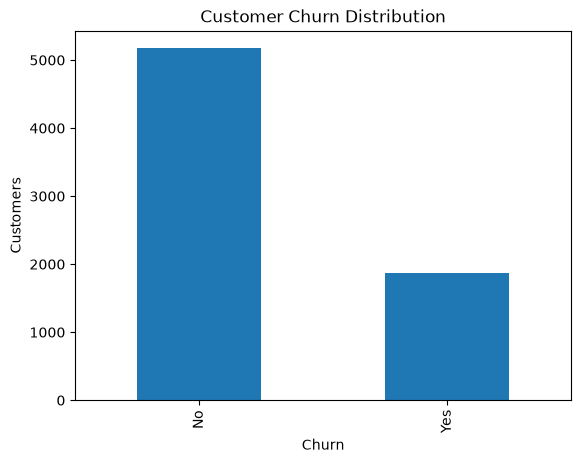

In [9]:
df["Churn"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customers")

### Вывод

Целевая переменная является несбалансированной:

- около 73.5% клиентов не ушли;
- около 26.5% клиентов ушли.

Поэтому одной Accuracy будет недостаточно для оценки моделей.
В дальнейшем будем дополнительно использовать Precision, Recall, F1-score
и ROC-AUC.

## 3. Проверка и обработка TotalCharges

Признак `TotalCharges` содержит суммарную сумму платежей клиента.

В исходном датасете этот столбец хранится как строковый тип, поэтому
сначала преобразуем его в числовой формат и проверим появившиеся
пропуски.

In [10]:
df["TotalCharges"].head(20)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: str

In [11]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print(
    f"Пропущенных значений в TotalCharges: "
    f"{df['TotalCharges'].isna().sum()}"
)

Пропущенных значений в TotalCharges: 11


In [12]:
df[df["TotalCharges"].isna()][
    ["customerID", "tenure", "Churn"]
]

,customerID,tenure,Churn
488,4472-LVYGI,0,No
753,3115-CZMZD,0,No
936,5709-LVOEQ,0,No
1082,4367-NUYAO,0,No
1340,1371-DWPAZ,0,No
3331,7644-OMVMY,0,No
3826,3213-VVOLG,0,No
4380,2520-SGTTA,0,No
5218,2923-ARZLG,0,No
6670,4075-WKNIU,0,No


In [13]:
df.loc[
    df["tenure"] == 0,
    "TotalCharges"
] = 0

In [15]:
df["TotalCharges"].isna().sum()

np.int64(0)

## 4. Сравнение клиентов по факту оттока

Сравним основные числовые признаки для двух групп клиентов:

- клиентов, которые остались;
- клиентов, которые ушли.

Особое внимание уделим `tenure`, `MonthlyCharges` и `TotalCharges`.

In [21]:
df.groupby("Churn")[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.569965,61.265124,2549.911442
Yes,17.979133,74.441332,1531.796094


### Вывод

В среднем ушедшие клиенты имеют меньший `tenure` и более высокие
`MonthlyCharges`, чем оставшиеся клиенты.

Средний `TotalCharges` у ушедших клиентов также ниже, что связано в том
числе с меньшей продолжительностью использования услуг.

Полученные различия характеризуют наблюдаемые взаимосвязи в данных и
не означают причинно-следственной зависимости.

## 5. Анализ категориальных признаков

Исследуем, как доля ушедших клиентов отличается между категориями
основных категориальных признаков.

Для сравнения будем использовать churn rate — долю клиентов с `Churn = Yes`
внутри каждой категории.

In [16]:
def churn_rate_by_category(df, feature):
    return (
        df.groupby(feature)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
        .round(2)
    )

In [18]:
categorical_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "OnlineSecurity",
    "TechSupport"
]

for feature in categorical_features:
    print(f"\n{feature}:")
    display(churn_rate_by_category(df, feature))


Contract:


Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


InternetService:


InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64


PaymentMethod:


PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn, dtype: float64


OnlineSecurity:


OnlineSecurity
No                     41.77
Yes                    14.61
No internet service     7.40
Name: Churn, dtype: float64


TechSupport:


TechSupport
No                     41.64
Yes                    15.17
No internet service     7.40
Name: Churn, dtype: float64

In [ ]:
def plot_churn_rate(df, feature):

    rates = churn_rate_by_category(df, feature)

    plt.figure(figsize=(8,4))

    sns.barplot(
        x=rates.values,
        y=rates.index
    )

    plt.xlabel("Churn rate (%)")
    plt.ylabel(feature)
    plt.title(f"Churn Rate by {feature}")

    plt.show()


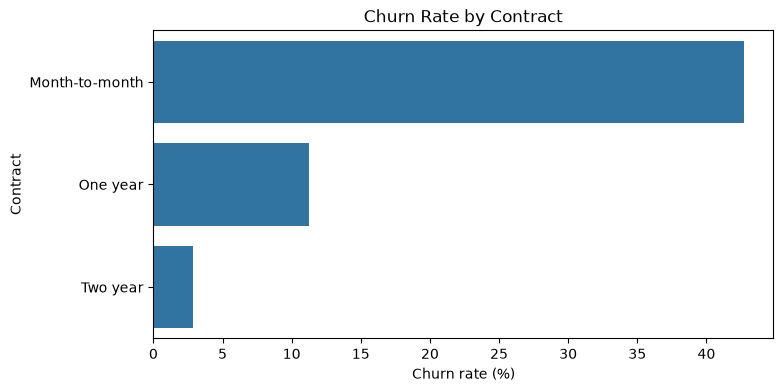

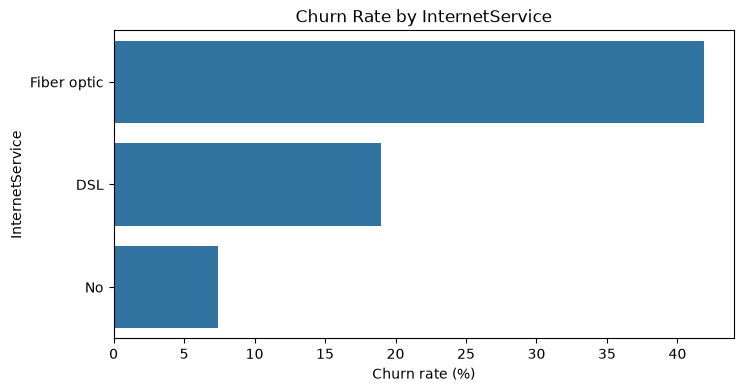

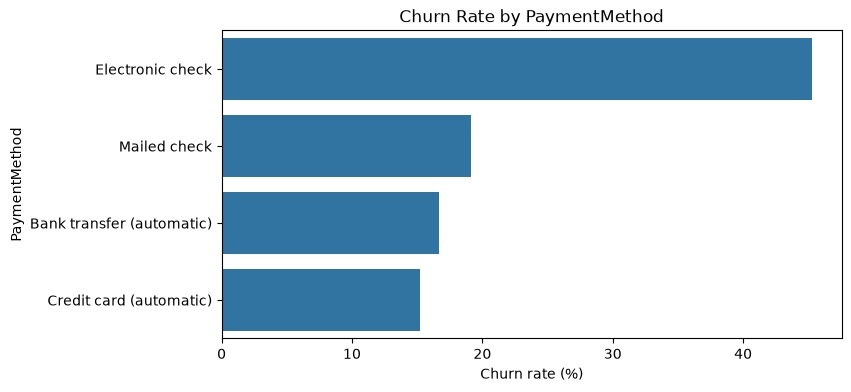

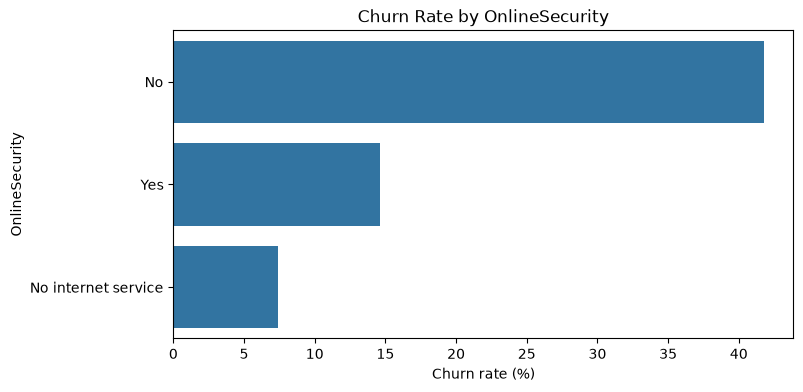

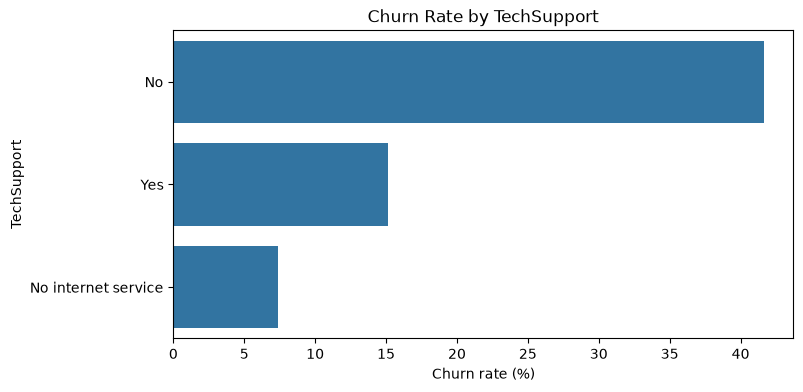

In [20]:
for feature in categorical_features:
    plot_churn_rate(df, feature)

### Вывод

Между категориями некоторых признаков наблюдаются заметные различия в
доле оттока.

Наиболее выраженные различия наблюдаются для:

- `Contract` — клиенты с помесячным контрактом имеют значительно более
  высокую долю оттока, чем клиенты с контрактами на один или два года;
- `InternetService` — для клиентов с `Fiber optic` доля оттока выше,
  чем для клиентов с `DSL`;
- `PaymentMethod` — для клиентов, использующих `Electronic check`,
  наблюдается высокая доля оттока.

Эти признаки представляют интерес для дальнейшего моделирования.
Наблюдаемые различия являются статистическими взаимосвязями и сами по
себе не доказывают причинного влияния признаков на отток.

## 6. Распределение числовых признаков

Рассмотрим распределение основных числовых признаков и сравним их
между клиентами, которые остались, и клиентами, которые ушли.

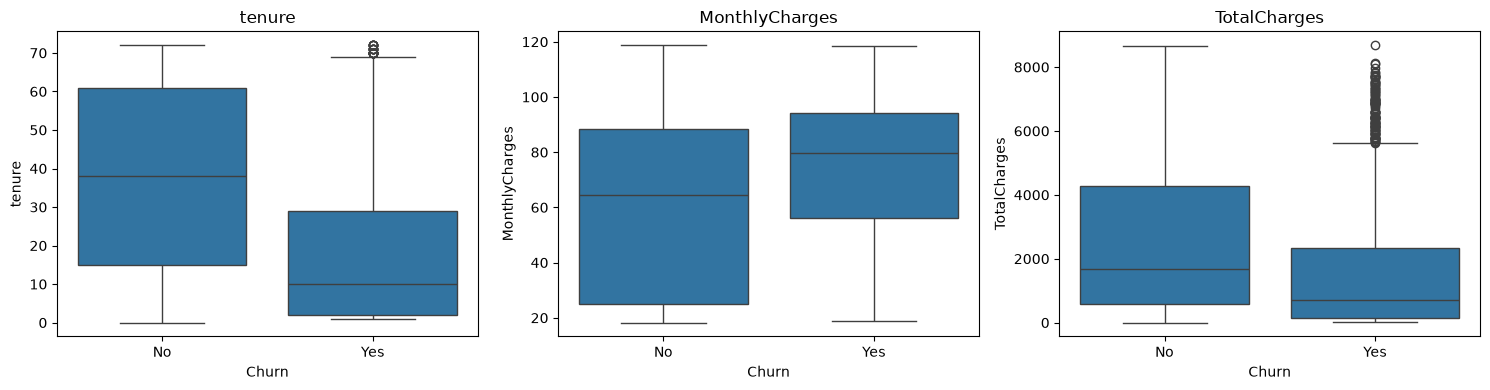

In [21]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,4)
)

for ax, feature in zip(axes, numeric_features):

    sns.boxplot(
        data=df,
        x="Churn",
        y=feature,
        ax=ax
    )
    ax.set_title(feature)
    ax.set_xlabel("Churn")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

## 7. Корреляционный анализ

Рассмотрим корреляции между числовыми признаками.

Корреляция показывает силу линейной связи между признаками, но не
позволяет делать вывод о причинно-следственной зависимости.

In [22]:

corr = df[numeric_features].corr(method='spearman')
corr

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.276417,0.889696
MonthlyCharges,0.276417,1.000000,0.638028
TotalCharges,0.889696,0.638028,1.000000


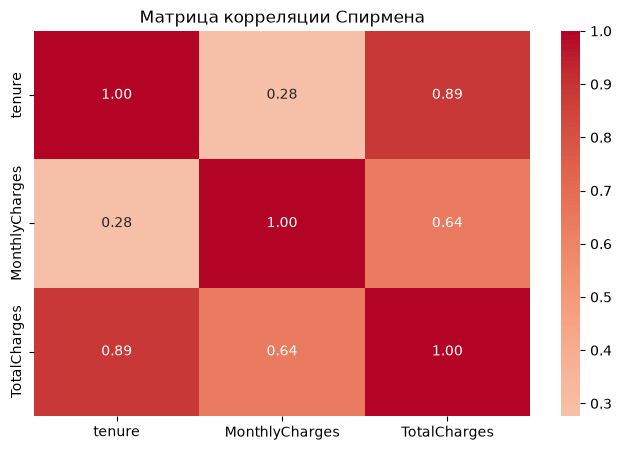

In [ ]:


plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0
)

plt.title("Матрица корреляции Спирмена")
plt.show()

## 8. EDA Summary

В результате исследовательского анализа были выявлены следующие особенности
данных:

1. Целевая переменная `Churn` несбалансирована: около 26.5% клиентов
   относятся к классу ушедших клиентов.

2. В `TotalCharges` обнаружены 11 пропущенных значений. Они относятся
   к клиентам с `tenure = 0`, поэтому для них `TotalCharges` принимается
   равным 0.

3. Ушедшие клиенты в среднем имеют меньший `tenure` и более высокие
   `MonthlyCharges`.

4. Значительные различия в churn rate наблюдаются между категориями
   `Contract`, `InternetService` и `PaymentMethod`.

5. Между `tenure` и `TotalCharges` наблюдается выраженная положительная
   корреляция.

6. Категориальные признаки требуют кодирования, а числовые признаки
   будут масштабированы перед обучением моделей.

Полученные результаты используются при построении preprocessing pipeline
и выборе моделей в следующих этапах проекта.